分子表征方法

In [1]:
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
from seq_encode.smiles import smiles_coder
from rdkit.Chem import rdFingerprintGenerator
import numpy as np
from rdkit.Chem import DataStructs


# load data
with open("/home/hwx/python_project/test/Boron/V3/processed_data/additives.json", "r") as f:
    data = json.load(f)

smiles_strings = [values['smiles'] for values in data.values()]
coder = smiles_coder()
coder.fit(smiles_strings)

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

fp_representation_list = []
onehot_representation_list = []
for key, values in data.items():
    smile = values['smiles']
    mol = Chem.MolFromSmiles(smile)
    
    # fingerprint
    fp = morgan_gen.GetFingerprint(mol)  
    output_fp = np.zeros((1,))
    DataStructs.ConvertToNumpyArray(fp, output_fp)

    # one-hot
    smile = [smile]
    output_onehot = coder.transform(smile)

    fp_representation_list.append(output_fp)
    onehot_representation_list.append(output_onehot)


# Convert lists to numpy arrays
fp_array = np.array(fp_representation_list)
onehot_array = np.array(onehot_representation_list)
print(f"Fingerprint array shape: {fp_array.shape}")
print(f"One-hot array shape: {onehot_array.shape}")





100%|██████████| 1/1 [00:00<00:00, 17403.75it/s]

Fingerprint array shape: (126, 1024)
One-hot array shape: (126, 1, 150, 30)


fingerprint

/tmp/ipykernel_1334951/3465716918.py:38: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(X, method='average', metric='cosine')
/home/hwx/envs/boron/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


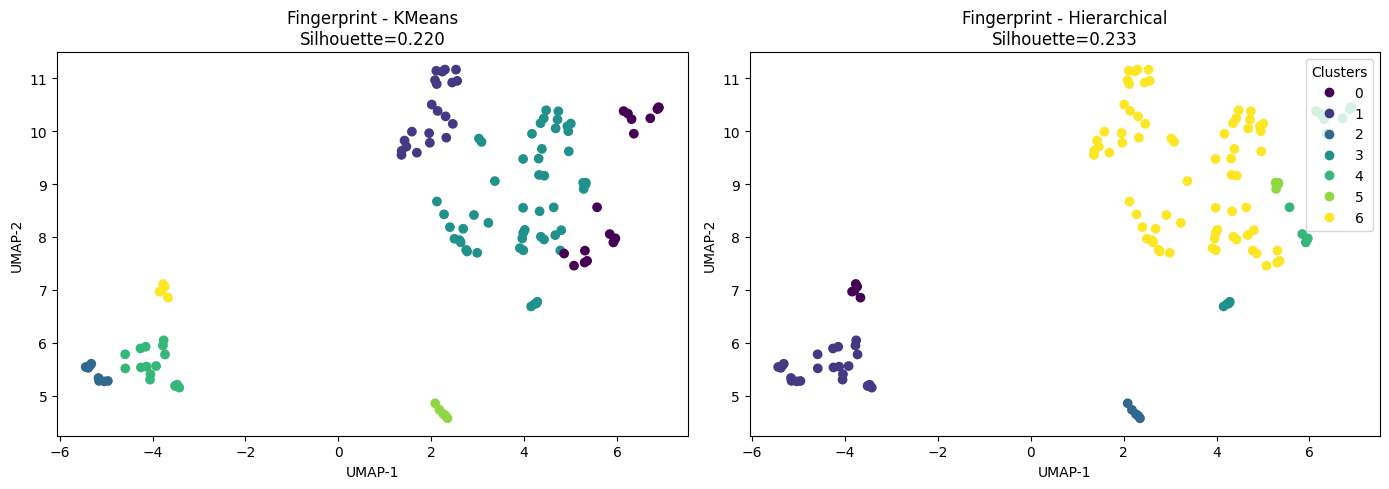

Fingerprint KMeans silhouette: 0.22034242474686133
Fingerprint Hierarchical silhouette: 0.23251570963698834


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster
import umap

def tanimoto_matrix(X):
    intersection = X @ X.T
    bit_sum = X.sum(axis=1)
    union = bit_sum[:, None] + bit_sum[None, :] - intersection
    union = np.where(union == 0, 1, union)
    sim = intersection / union
    return sim

def run_clustering(X, title, n_clusters=7):
    sim_matrix = tanimoto_matrix(X)
    # 转化为距离矩阵用于降维
    dist_matrix = 1 - sim_matrix
    np.fill_diagonal(dist_matrix, 0)  # 对角线必须为 0

    X = dist_matrix

    # =====================
    # KMeans
    # =====================

    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels_kmeans = kmeans.fit_predict(X)
    sil_kmeans = silhouette_score(X, labels_kmeans)


    # =====================
    # Hierarchical (linkage)
    # =====================

    Z = linkage(X, method='average', metric='cosine')
    labels_hier = fcluster(Z, n_clusters, criterion='maxclust')
    sil_hier = silhouette_score(X, labels_hier)


    # =====================
    # UMAP降维
    # =====================
    reducer = umap.UMAP(random_state=42)
    X_umap = reducer.fit_transform(X)


    # =====================
    # Plot
    # =====================

    fig = plt.figure(figsize=(14,5))

    ax1 = plt.subplot(1,2,1)
    sc1 = ax1.scatter(X_umap[:,0], X_umap[:,1], c=labels_kmeans)
    ax1.set_title(f"{title} - KMeans\nSilhouette={sil_kmeans:.3f}")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")


    ax2 = plt.subplot(1,2,2)
    sc2 = ax2.scatter(X_umap[:,0], X_umap[:,1], c=labels_hier)
    ax2.set_title(f"{title} - Hierarchical\nSilhouette={sil_hier:.3f}")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")

    plt.legend(*sc1.legend_elements(), title="Clusters", loc='upper right')
    plt.tight_layout()
    plt.show()


    print(f"{title} KMeans silhouette:", sil_kmeans)
    print(f"{title} Hierarchical silhouette:", sil_hier)


# ======================
# 运行
# ======================
run_clustering(fp_array, "Fingerprint")

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, emb_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, emb_dim)
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=1)

def info_nce_loss(z1, z2, temperature=0.5):
    """
    z1, z2: shape [N, d]
    """
    z1 = F.normalize(z1, dim=-1)
    z2 = F.normalize(z2, dim=-1)
    N = z1.size(0)
    
    sim_matrix = torch.mm(z1, z2.t()) / temperature
    labels = torch.arange(N).to(z1.device)
    loss = F.cross_entropy(sim_matrix, labels)
    return loss

def augment(x, drop_prob=0.1):
    mask = np.random.rand(*x.shape) > drop_prob
    return x * mask

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


def unsupervised_training(pos_train_samples, pos_test_samples):
    # Unsupervised training
    model = Encoder(input_dim=pos_train_samples.shape[1]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=5e-4)
    
    unsuper_train_loss = []
    silhouette_scores = 0
    best_model = None
    best_embeddings = None
    best_labels = None
    for epoch in tqdm(range(1, 501), desc='Training the representation FP/SMILES ...'):
        model.train()

        # graph augmentation: for constractive learning 
        x1 = torch.tensor(augment(pos_train_samples), dtype=torch.float32).to(device)
        x2 = torch.tensor(augment(pos_train_samples), dtype=torch.float32).to(device) 
        
        z1 = model(x1)
        z2 = model(x2)

        loss = info_nce_loss(z1, z2)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        unsuper_train_loss.append(loss)

        model.eval()

        all_embeddings = []
        with torch.no_grad():
            x = torch.tensor(augment(pos_train_samples), dtype=torch.float32).to(device)
            out = model(x)
            all_embeddings.append(out.cpu())

        all_embeddings = F.normalize(torch.cat(all_embeddings), dim=-1).numpy()

        # # hierarchical cluster
        # Z = linkage(all_embeddings, method='average', metric='cosine')
        # labels = fcluster(Z, t=7, criterion='maxclust')
        # sil = silhouette_score(all_embeddings, labels, metric='cosine')

        # KMeans clustering
        kmeans = KMeans(n_clusters=7, random_state=42, n_init=20)
        labels = kmeans.fit_predict(all_embeddings)
        sil = silhouette_score(all_embeddings, labels, metric='cosine')

        if sil > silhouette_scores:
            silhouette_scores = sil
            best_embeddings = all_embeddings
            best_labels = labels
            best_model = model.state_dict()
    
    return best_embeddings, best_labels, silhouette_scores, best_model

print('Training samples:', len(onehot_array))
onehot_array = onehot_array.reshape(onehot_array.shape[0], -1)

best_model_global = None
best_label = None
best_sil_score = -1
for trial in tqdm(range(10), desc=f'Unsupervised learning trials...'):
    best_embeddings, best_labels, silhouette_scores, best_model = unsupervised_training(onehot_array, [])
    if silhouette_scores > best_sil_score:
        best_sil_score = silhouette_scores
        best_label = best_labels
        best_model_global = best_model
        best_embeddings_global = best_embeddings
        best_trial = trial + 1

print(f'Best trial from unsupervised learning: {best_trial}')
print(f'Best silhouette score from unsupervised learning: {best_sil_score}')


sil = silhouette_score(best_embeddings_global, best_label, metric='cosine')

reducer = umap.UMAP(random_state=42, metric='cosine')
umap_embeds = reducer.fit_transform(best_embeddings_global)

# 可视化不同簇在UMAP上的分布
plt.figure(figsize=(8,6))
label_num = len(set(best_label))
for i in range(1, label_num + 1):
    plt.scatter(umap_embeds[best_label==i, 0], umap_embeds[best_label==i, 1], s=40, label=f"Cluster {i}", alpha=0.7)
plt.legend()
plt.title(f"UMAP Projection (Silhouette = {sil:.4f})")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()

Training samples: 126


Unsupervised learning trials...:  90%|█████████ | 9/10 [07:23<00:49, 49.23s/it]


KeyboardInterrupt: 

SMILES

/home/hwx/envs/boron/lib/python3.9/site-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/home/hwx/envs/boron/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


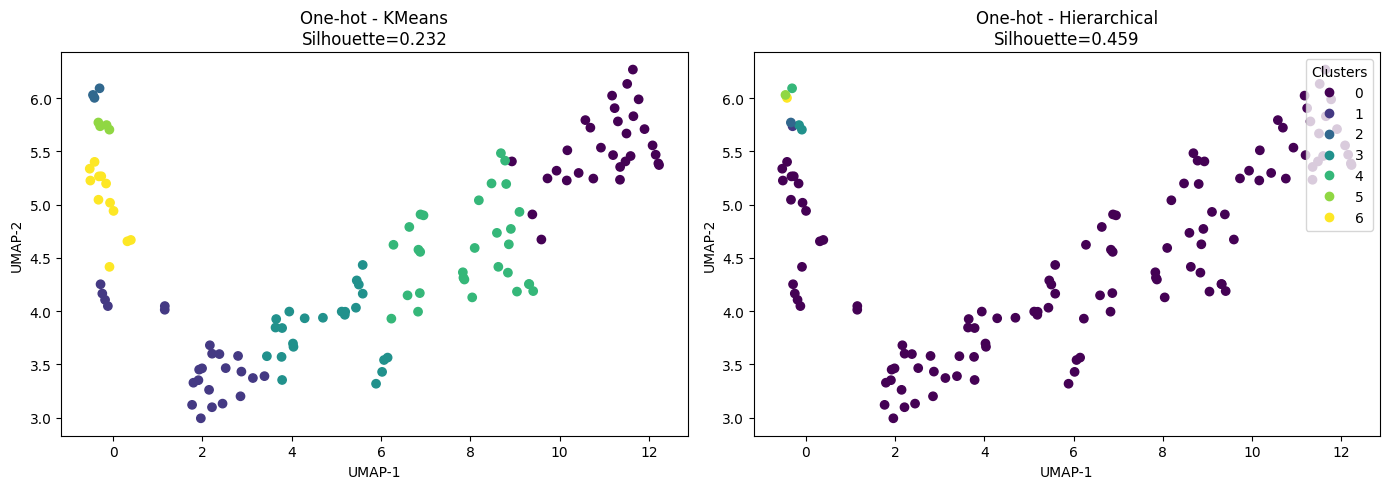

One-hot KMeans silhouette: 0.23180348398730444
One-hot Hierarchical silhouette: 0.45932851934576235


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import pairwise_distances
import umap


def run_clustering(X, title, n_clusters=7):
    X = X.reshape(X.shape[0], -1)  # Flatten if needed
    dist = pairwise_distances(X, metric="jaccard")
    sim = 1 - dist

    X = sim

    # =====================
    # KMeans
    # =====================

    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels_kmeans = kmeans.fit_predict(X)
    sil_kmeans = silhouette_score(X, labels_kmeans)


    # =====================
    # Hierarchical (linkage)
    # =====================

    Z = linkage(X, method='average', metric='cosine')
    labels_hier = fcluster(Z, n_clusters, criterion='maxclust')
    sil_hier = silhouette_score(X, labels_hier)


    # =====================
    # UMAP降维
    # =====================
    reducer = umap.UMAP(random_state=42)
    X_umap = reducer.fit_transform(X)


    # =====================
    # Plot
    # =====================

    fig = plt.figure(figsize=(14,5))

    ax1 = plt.subplot(1,2,1)
    sc1 = ax1.scatter(X_umap[:,0], X_umap[:,1], c=labels_kmeans)
    ax1.set_title(f"{title} - KMeans\nSilhouette={sil_kmeans:.3f}")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")


    ax2 = plt.subplot(1,2,2)
    sc2 = ax2.scatter(X_umap[:,0], X_umap[:,1], c=labels_hier)
    ax2.set_title(f"{title} - Hierarchical\nSilhouette={sil_hier:.3f}")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")

    plt.legend(*sc1.legend_elements(), title="Clusters", loc='upper right')
    plt.tight_layout()
    plt.show()


    print(f"{title} KMeans silhouette:", sil_kmeans)
    print(f"{title} Hierarchical silhouette:", sil_hier)


# ======================
# 运行
# ======================

run_clustering(onehot_array, "One-hot")

GNN

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Linear, Dropout, Sequential, ReLU, MultiheadAttention, LayerNorm, BatchNorm1d
from torch_geometric.nn import GraphNorm
from torch_geometric.nn import (
    GraphNorm,
    GCNConv,
    GINEConv,
    GINConv,
    GATConv,
    global_mean_pool
)


class ProjectionHead(nn.Module):
    def __init__(self, in_dim, proj_dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, in_dim),
            nn.ReLU(),
            nn.Linear(in_dim, proj_dim),
        )

    def forward(self, x):
        return self.mlp(x)


class Cluster_GINE(torch.nn.Module):
    def __init__(self, num_node_features, num_edge_features, hidden_channels, num_classes, dropout):
        super(Cluster_GINE, self).__init__()

        nn1 = Sequential(Linear(num_node_features, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv1 = GINEConv(nn1, edge_dim=num_edge_features)
        self.norm1 = GraphNorm(hidden_channels)

        nn2 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv2 = GINEConv(nn2, edge_dim=num_edge_features)
        self.norm2 = GraphNorm(hidden_channels)

        nn3 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv3 = GINEConv(nn3, edge_dim=num_edge_features)
        self.norm3 = GraphNorm(hidden_channels)

        self.dropout = Dropout(dropout)

    def forward(self, x, edge_index, edge_attr, batch): 
        x = self.conv1(x, edge_index, edge_attr)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = self.norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index, edge_attr)
        x = self.norm3(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = global_mean_pool(x, batch)

        return x

class Cluster_GCN(torch.nn.Module):
    def __init__(self, num_node_features, num_edge_features, hidden_channels, num_classes, dropout):
        super(Cluster_GCN, self).__init__()

        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.norm1 = GraphNorm(hidden_channels)

        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.norm2 = GraphNorm(hidden_channels)

        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.norm3 = GraphNorm(hidden_channels)

        self.dropout = Dropout(dropout)

    def forward(self, x, edge_index, edge_attr, batch):
        # GCN 不使用 edge_attr
        x = self.conv1(x, edge_index)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        x = self.norm3(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = global_mean_pool(x, batch)

        return x

class Cluster_GIN(torch.nn.Module):
    def __init__(self, num_node_features, num_edge_features, hidden_channels, num_classes, dropout):
        super(Cluster_GIN, self).__init__()

        nn1 = Sequential(
            Linear(num_node_features, hidden_channels),
            ReLU(),
            Linear(hidden_channels, hidden_channels)
        )
        self.conv1 = GINConv(nn1)
        self.norm1 = GraphNorm(hidden_channels)

        nn2 = Sequential(
            Linear(hidden_channels, hidden_channels),
            ReLU(),
            Linear(hidden_channels, hidden_channels)
        )
        self.conv2 = GINConv(nn2)
        self.norm2 = GraphNorm(hidden_channels)

        nn3 = Sequential(
            Linear(hidden_channels, hidden_channels),
            ReLU(),
            Linear(hidden_channels, hidden_channels)
        )
        self.conv3 = GINConv(nn3)
        self.norm3 = GraphNorm(hidden_channels)

        self.dropout = Dropout(dropout)

    def forward(self, x, edge_index, edge_attr, batch):
        # GIN 不使用 edge_attr
        x = self.conv1(x, edge_index)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        x = self.norm3(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = global_mean_pool(x, batch)

        return x

class Cluster_GAT(torch.nn.Module):
    def __init__(self, num_node_features, num_edge_features, hidden_channels, num_classes, dropout, heads=4):
        super(Cluster_GAT, self).__init__()

        self.conv1 = GATConv(
            in_channels=num_node_features,
            out_channels=hidden_channels,
            heads=heads,
            concat=False,
            dropout=dropout,
            edge_dim=num_edge_features
        )
        self.norm1 = GraphNorm(hidden_channels)

        self.conv2 = GATConv(
            in_channels=hidden_channels,
            out_channels=hidden_channels,
            heads=heads,
            concat=False,
            dropout=dropout,
            edge_dim=num_edge_features
        )
        self.norm2 = GraphNorm(hidden_channels)

        self.conv3 = GATConv(
            in_channels=hidden_channels,
            out_channels=hidden_channels,
            heads=heads,
            concat=False,
            dropout=dropout,
            edge_dim=num_edge_features
        )
        self.norm3 = GraphNorm(hidden_channels)

        self.dropout = Dropout(dropout)

    def forward(self, x, edge_index, edge_attr, batch):
        # GAT 可以使用 edge_attr
        x = self.conv1(x, edge_index, edge_attr=edge_attr)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index, edge_attr=edge_attr)
        x = self.norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index, edge_attr=edge_attr)
        x = self.norm3(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = global_mean_pool(x, batch)

        return x

In [2]:
import torch
from tqdm import tqdm
from torch_geometric.utils import subgraph
from torch_geometric.utils import to_networkx, from_networkx
import networkx as nx
import random
from torch_geometric.utils import to_dense_adj, dense_to_sparse
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

class Graph_Augmentation_Helper():
    def __init__(self, positive_samples, args):
        self.pos_samples = positive_samples
        self.aug_types = args.aug_types
        self.random_state = args.random_state
        self.test_size = args.test_size

        # augmentation configs
        self.shuffle_ratio = args.shuffle_ratio
        self.noise_ratio = args.noise_ratio
        self.noise_std = args.noise_std
        self.node_drop_ratio = args.node_drop_ratio
        self.edge_drop_ratio = args.edge_drop_ratio
        self.edge_add_ratio = args.edge_add_ratio
        self.alpha = args.alpha
        self.PPR_drop_ratio = args.PPR_drop_ratio
        self.PPR_add_ratio = args.PPR_add_ratio
        self.K = args.K


    def node_feature_shuffle(self, samples, shuffle_ratio):
        shuffled_samples = []
        for data in tqdm(samples, desc='Augment graph by node feature shuffling...'):
            num_features = data.x.size(1)
            num_shuffle = int(num_features * shuffle_ratio)

            perm = torch.randperm(num_features)
            shuffle_idx = perm[:num_shuffle]

            shuffled_x = data.x.clone()
            shuffled_x[:, shuffle_idx] = data.x[torch.randperm(data.x.size(0))][:, shuffle_idx]

            new_data = data.clone()
            new_data.x = shuffled_x
            new_data.id = int(str(data.id) + '000')
            shuffled_samples.append(new_data)

        return shuffled_samples
    

    def node_feature_noise_masking(self, samples, noise_ratio, noise_std):
        noise_masked_samples = []
        for data in tqdm(samples, desc='Augment graph by noise masking...'):
            x = data.x.clone()

            mask = torch.rand_like(x) < noise_ratio  

            noise = torch.randn_like(x) * noise_std
            x_noisy = x + noise * mask 

            new_data = data.clone()
            new_data.x = x_noisy
            new_data.id = int(str(data.id) + '001')
            noise_masked_samples.append(new_data)
        
        return noise_masked_samples


    def node_dropping(self, samples, drop_ratio=0.2):
        """

        """
        dropped_samples = []
        for data in tqdm(samples, desc='Augment graph by node dropping...'):
            num_nodes = data.n_nodes
            
            num_drop = max(1, int(num_nodes * drop_ratio))  # at less drop one node
            drop_nodes = torch.randperm(num_nodes)[:num_drop]
            
            keep_mask = torch.ones(num_nodes, dtype=torch.bool)
            keep_mask[drop_nodes] = False
            keep_nodes = keep_mask.nonzero(as_tuple=False).view(-1)
            
            edge_index, edge_attr = subgraph(
                subset=keep_nodes,
                edge_index=data.edge_index,
                edge_attr=data.edge_attr if hasattr(data, "edge_attr") else None,
                relabel_nodes=True, 
                num_nodes=num_nodes
            )
            
            new_data = data.clone()
            new_data.x = data.x[keep_nodes]
            new_data.edge_index = edge_index
            new_data.edge_attr = edge_attr
            new_data.n_nodes = keep_nodes.size(0)
            new_data.id = int(str(data.id) + '010')
            dropped_samples.append(new_data)
        
        return dropped_samples
    

    def edge_perturbation_weighted(self, samples, drop_ratio, add_ratio):
        """

        """
        edge_perturbation_weighted_samples = []
        for data in tqdm(samples, desc='Augment graph by edge perturbation weighting...'):
            num_nodes = data.x.size(0)
            G = to_networkx(data, to_undirected=True)
            nodes_list = range(num_nodes)
            center_node = random.choice(nodes_list)
             
            lengths = dict(nx.single_source_shortest_path_length(G, center_node))

            max_hop = max(lengths.values()) if lengths else 0
            default_hop = max_hop + 1
            
            deg = dict(G.degree())
            
            edge_list = list(G.edges())
            edge_weights = []
            for (u, v) in edge_list:

                hop_u = lengths.get(u, default_hop)
                hop_v = lengths.get(v, default_hop)
                hop = min(hop_u, hop_v)

                d_u = deg[u]
                d_v = deg[v]
                d = max(d_u, d_v)

                w = (1.0 / (hop + 1)) * (d / (d + 1))
                edge_weights.append(w)
 
            weights = torch.tensor(edge_weights, dtype=torch.float)
            probs = weights / weights.sum()
            

            num_drop = max(1, int(len(edge_list) * drop_ratio))
            drop_idx = torch.multinomial(probs, num_drop, replacement=False).tolist()
            drop_edges = [edge_list[i] for i in drop_idx]
            for (u,v) in drop_edges:
                if G.has_edge(u,v):
                    G.remove_edge(u, v)

            num_add = int(len(edge_list) * add_ratio)

            node_pairs = []
            attempts = 0
            while len(node_pairs) < num_add and attempts < num_add * 10:
                u = random.randrange(num_nodes)
                v = random.randrange(num_nodes)
                if u==v or G.has_edge(u,v):
                    attempts += 1
                    continue

                hop_u = lengths.get(u, default_hop)
                hop_v = lengths.get(v, default_hop)
                if abs(hop_u - hop_v) > 0:  
                    G.add_edge(u, v)
                    node_pairs.append((u, v))
                attempts += 1
            

            new_edge_index = from_networkx(G)
            new_data = data.clone()
            new_data.x = data.x
            new_data.edge_index = new_edge_index.edge_index
            if hasattr(data, 'edge_attr'):
                new_data.edge_attr = torch.zeros((new_data.edge_index.size(1), data.edge_attr.size(1)))
            new_data.id = int(str(data.id) + '011')
            
            edge_perturbation_weighted_samples.append(new_data)

        return edge_perturbation_weighted_samples
    

    def personalized_pagerank_augmentation(self, samples, alpha, drop_ratio, add_ratio, K):
        """
        Personalized PageRank (PPR) based graph augmentation
        Args:
            data: PyG Data 对象
            alpha: teleport 概率（默认 0.15）
            drop_ratio: 删除边比例
            add_ratio: 添加边比例
        """
        PPR_samples = []

        for data in tqdm(samples, desc='Augment graph by personalized pagerank...'):
            num_nodes = data.num_nodes
            edge_index = data.edge_index

            # Step 1: 构建对称邻接矩阵
            A = to_dense_adj(edge_index, max_num_nodes=num_nodes).squeeze(0)
            A = (A + A.t()) / 2
            A.fill_diagonal_(0)

            # Step 2: 归一化邻接矩阵
            deg = A.sum(dim=1)
            deg_inv_sqrt = torch.pow(deg, -0.5)
            deg_inv_sqrt[torch.isinf(deg_inv_sqrt)] = 0
            D_inv_sqrt = torch.diag(deg_inv_sqrt)
            A_hat = D_inv_sqrt @ A @ D_inv_sqrt

            # Step 3: 近似计算 Personalized PageRank 矩阵
            P = torch.eye(num_nodes)
            M = torch.eye(num_nodes)
            for _ in range(K):
                M = (1 - alpha) * A_hat @ M
                P += M
            P = alpha * P

            # Step 4: 删除边
            edge_list = edge_index.t().tolist()
            edge_scores = [P[i, j].item() for i, j in edge_list]
            num_drop = int(len(edge_list) * drop_ratio)
            if num_drop > 0:
                weights = torch.tensor(edge_scores)
                weights = (weights.max() - weights + 1e-8)  # 分数越小越容易被删
                weights = weights / weights.sum()
                drop_idx = torch.multinomial(weights, num_drop, replacement=False)
                keep_edges = [edge_list[i] for i in range(len(edge_list)) if i not in drop_idx]
            else:
                keep_edges = edge_list

            # Step 5: 添加边
            adj = A.clone()
            num_add = int(len(keep_edges) * add_ratio)
            if num_add > 0:
                candidates = [(i, j) for i in range(num_nodes) for j in range(num_nodes)
                            if adj[i, j] == 0 and i != j]
                if len(candidates) > 0:
                    candidate_scores = torch.tensor([P[i, j].item() for i, j in candidates])
                    probs = candidate_scores / candidate_scores.sum()
                    add_idx = torch.multinomial(probs, min(num_add, len(candidates)), replacement=False)
                    add_edges = [candidates[i] for i in add_idx]
                    keep_edges += add_edges

            new_edge_index = torch.tensor(keep_edges).t().contiguous()

            # Step 6: 构建增强后的图
            new_data = data.clone()
            new_data.edge_index = new_edge_index
            new_data.n_edges = new_edge_index.size(1)
            new_data.edge_attr = data.edge_attr[:new_edge_index.size(1)]  # 直接截断（或重新初始化）
            new_data.id = int(str(data.id) + '100')

            PPR_samples.append(new_data)

        return PPR_samples
    

    def do_augmentation(self):
        print('Start to augment graph data')

        if self.aug_types == 'all':
            # feature-level augmentation
            node_mixup_samples = self.node_feature_shuffle(self.pos_samples, self.shuffle_ratio)
            noise_masking_samples = self.node_feature_noise_masking(self.pos_samples, self.noise_ratio, self.noise_std)
            
            # node and edge level augmentation
            node_dropping_samples = self.node_dropping(self.pos_samples, self.node_drop_ratio)
            edge_perturbation_weighted_samples = self.edge_perturbation_weighted(self.pos_samples, self.edge_drop_ratio, self.edge_add_ratio)

            # graph-level augmetation
            PPR_samples = self.personalized_pagerank_augmentation(self.pos_samples, self.alpha, self.PPR_drop_ratio, self.PPR_add_ratio, self.K)
        
        return self.pos_samples, node_mixup_samples, noise_masking_samples, node_dropping_samples, edge_perturbation_weighted_samples, PPR_samples


    def train_test_split_positive_samples(self):
        pos_samples, node_mixup_samples, noise_masking_samples, node_dropping_samples, edge_perturbation_weighted_samples, PPR_samples = self.do_augmentation()
        
        # split train, test set
        pos_train_set, pos_test_set = train_test_split(pos_samples, test_size=self.test_size, random_state=self.random_state)
        node_mixup_train_set, node_mixup_test_set = train_test_split(node_mixup_samples, test_size=self.test_size, random_state=self.random_state)
        noise_mask_train_set, noise_mask_test_set = train_test_split(noise_masking_samples, test_size=self.test_size, random_state=self.random_state)
        node_drop_train_set, node_drop_test_set = train_test_split(node_dropping_samples, test_size=self.test_size, random_state=self.random_state)
        edge_weight_train_set, edge_weight_test_set = train_test_split(edge_perturbation_weighted_samples, test_size=self.test_size, random_state=self.random_state)
        PPR_train_set, PPR_test_set = train_test_split(PPR_samples, test_size=self.test_size, random_state=self.random_state)

        pos_train_samples = pos_train_set + node_mixup_train_set + noise_mask_train_set + node_drop_train_set + edge_weight_train_set + PPR_train_set
        pos_test_samples = pos_test_set + node_mixup_test_set + noise_mask_test_set + node_drop_test_set + edge_weight_test_set + PPR_test_set

        return pos_train_samples, pos_test_samples


In [3]:
import pickle

# data preparation
with open('/home/hwx/python_project/test/Boron/data/all_data.pkl', 'rb') as f:
    all_data = pickle.load(f)

positive_samples = all_data[:126] # number of positive samples

Training samples: 126


Unsupervised learning trials...:  10%|█         | 1/10 [00:11<01:45, 11.77s/it]

Trial 1/10 | Best silhouette = 0.798347


Unsupervised learning trials...:  20%|██        | 2/10 [00:23<01:33, 11.70s/it]

Trial 2/10 | Best silhouette = 0.743518


...

Trial 8/10 | Best silhouette = 0.800758


Unsupervised learning trials...:  90%|█████████ | 9/10 [01:45<00:11, 11.75s/it]

Trial 9/10 | Best silhouette = 0.849945


Unsupervised learning trials...: 100%|██████████| 10/10 [01:57<00:00, 11.71s/it]
/home/hwx/envs/boron/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Trial 10/10 | Best silhouette = 0.767358

========== USL Silhouette Summary ==========
Model backbone: GINE
Number of trials: 10
Best trial: 9
Best silhouette score: 0.849945
Silhouette score: 0.798798 ± 0.029509
Time cost: 5.856210 ± 3.381179
All trial scores:
[0.7983472  0.7435183  0.8017434  0.7839911  0.80589753 0.8265931
 0.8098308  0.80075765 0.849945   0.7673577 ]



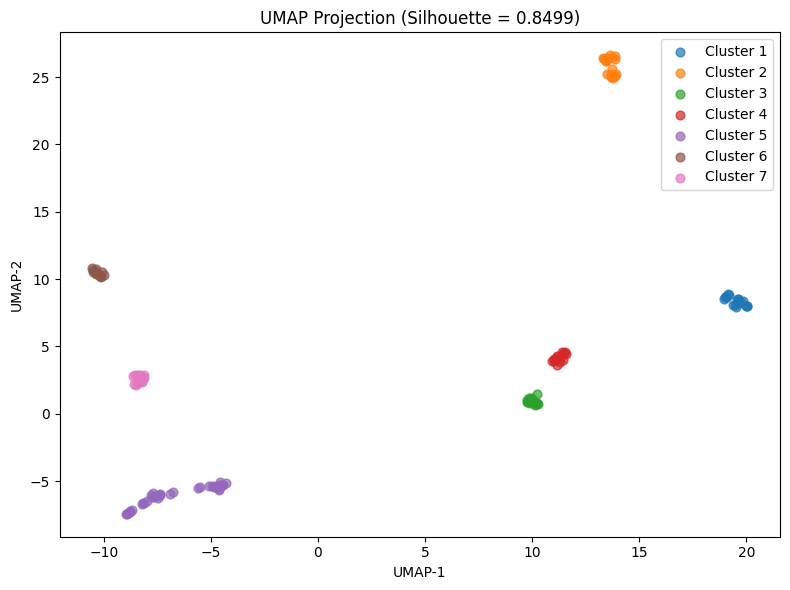

In [10]:
import torch
import random
from torch_geometric.loader import DataLoader
from tqdm import tqdm
import pickle
import argparse
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import pairwise_distances
import umap
import time

# graph augmentation configs
parser = argparse.ArgumentParser(description="Train the model")
parser.add_argument('--aug_types', type=str, default='all', help='augmentation types')
parser.add_argument('--shuffle_ratio', type=float, default=0.2, help='shuffle ratio')
parser.add_argument('--node_drop_ratio', type=float, default=0.2, help='node drop ratio')
parser.add_argument('--noise_ratio', type=float, default=0.2, help='noise_ratio')
parser.add_argument('--noise_std', type=float, default=0.1, help='noise_std')
parser.add_argument('--edge_drop_ratio', type=float, default=0.1, help='edge drop ratio')
parser.add_argument('--edge_add_ratio', type=float, default=0.05, help='edge add ratio')
parser.add_argument('--alpha', type=float, default=0.15, help='PPR alpha')
parser.add_argument('--PPR_drop_ratio', type=float, default=0.2, help='PPR_drop_ratio')
parser.add_argument('--PPR_add_ratio', type=float, default=0.2, help='PPR_add_ratio')
parser.add_argument('--K', type=int, default=10, help='PPR K')
parser.add_argument('--random_state', type=int, default=42, help='data split random seed')
parser.add_argument('--test_size', type=float, default=0.2, help='test set size')

parser.add_argument('--analysis', type=bool, default=False, help='Wether to print the summary of the dataset')
parser.add_argument('--usl_batch_size', type=int, default=256, help='Batch size for training')
parser.add_argument('--num_classes', type=int, default=2, help='Number of classes')
parser.add_argument('--usl_learning_rate', type=float, default=0.0005, help='Learning rate')
parser.add_argument('--usl_hidden_channels', type=int, default=256, help='Number of hidden channels')
parser.add_argument('--epoch', type=int, default=500, help='Number of training epochs')
parser.add_argument('--dropout', type=float, default=0.5, help='Value of dropout')
parser.add_argument('--training_types', type=str, default='Unsupervised learning', help='training_types')
parser.add_argument('--models', type=str, default='GINE', help='Training models')
parser.add_argument('--embed_dim', type=int, default=256, help='Embedding dimension of attention')
parser.add_argument('--num_heads', type=int, default=4, help='Number of heads for attention')
parser.add_argument('--desp_dim', type=int, default=217, help='Number of descriptors')
parser.add_argument('--retrain_usl', type=bool, default=False, help='retrain the usl models')
parser.add_argument('--usl_trials', type=int, default=10, help='Number of trials for unsupervised learning')
parser.add_argument('--save_path', type=str, default='checkpoints_top35', help='')

parser.add_argument('--max_cluster', type=int, default=10, help='max cluster number')
parser.add_argument('--temperature', type=float, default=0.1, help='temperature coefficient for prototypes')
parser.add_argument('--proto_epoch', type=int, default=300, help='Number of training epochs')
parser.add_argument('--r', type=int, default=10000, help='number of randomly select neg prototypes')
parser.add_argument('--proto_training_types', type=str, default='Prototype contrastive learning', help='training_types')
parser.add_argument('--proto_models', type=str, default='GINE', help='model name for PCL')
parser.add_argument('--pcl_hidden_channels', type=int, default=256, help='Number of hidden channels')
parser.add_argument('--pcl_learning_rate', type=float, default=0.00001, help='Learning rate')
parser.add_argument('--pcl_batch_size', type=int, default=1024, help='Batch size for training')
parser.add_argument('--threshold', type=float, default=0.3, help='threshold')
parser.add_argument('--topk', type=int, default=35, help='top k samples for each prototype')
parser.add_argument('--pcl_trials', type=int, default=10, help='Number of trials for unsupervised learning')
args = parser.parse_args(args=[])

def filter_cluster_outliers(embeddings, cluster_labels, alpha=1.5):
    filtered_embeddings = []
    filtered_labels = []
    filtered_indices = []

    unique_clusters = np.unique(cluster_labels)

    for cluster_id in unique_clusters:
        idx = np.where(cluster_labels == cluster_id)[0]
        cluster_emb = embeddings[idx]

        if len(cluster_emb) < 2:
            continue

        centroid = np.mean(cluster_emb, axis=0)
        distances = np.linalg.norm(cluster_emb - centroid, axis=1)

        # threshold = mean + α * std
        d_mean = distances.mean()
        d_std = distances.std()
        threshold = d_mean + alpha * d_std

        mask = distances <= threshold

        filtered_embeddings.append(cluster_emb[mask])
        filtered_labels.append(cluster_labels[idx][mask])
        filtered_indices.append(idx[mask])

    filtered_embeddings = np.vstack(filtered_embeddings)
    filtered_labels = np.concatenate(filtered_labels)
    filtered_indices = np.concatenate(filtered_indices)
    return filtered_embeddings, filtered_labels, filtered_indices

def try_multiple_cluster_combinations(Z, all_embeddings, pos_additives_names, args):
    possible_clusters = range(3, args.max_cluster+1)
    best_score = -1
    best_k = None
    best_labels = None
    best_embeddings = None
    best_names = None
    best_Z = None

    for k in possible_clusters:
        cluster_labels = fcluster(Z, t=k, criterion='maxclust')

        # filter the outliers in each cluster
        filtered_embeddings, filtered_labels, filtered_indices = filter_cluster_outliers(all_embeddings, cluster_labels)

        try:
            Z_filt = linkage(filtered_embeddings, method='average', metric='cosine')
            score = silhouette_score(filtered_embeddings, filtered_labels, metric='cosine')
            if score > best_score:
                best_score = score
                best_k = k
                best_labels = filtered_labels
                best_embeddings = filtered_embeddings
                if args.retrain_usl:
                    best_names = None
                else:
                    best_names = np.array(pos_additives_names)[filtered_indices].tolist()
                best_Z = Z_filt
        except Exception as e:
            print(f"k={k} failed: {e}")

    # print(f"\n✅ best cluster number: {best_k}, average silhouette score: {best_score:.4f}")

    return best_k, best_labels, best_embeddings, best_names, best_Z

def perturb_edges(data, device, perturb_ratio=0.1):
    edge_index = data.edge_index.clone()
    num_edges = edge_index.size(1)
    num_nodes = data.x.size(0)

    num_delete = int(num_edges * perturb_ratio / 2)
    mask = torch.ones(num_edges, dtype=torch.bool)
    del_indices = random.sample(range(num_edges), num_delete)
    mask[del_indices] = False
    edge_index = edge_index[:, mask]

    num_add = num_delete
    new_edges = torch.randint(0, num_nodes, (2, num_add), device=device)
    edge_index = torch.cat([edge_index, new_edges], dim=1)

    data.edge_index = edge_index
    return data


def info_nce_loss(z1, z2, temperature=0.5):
    """
    z1, z2: shape [N, d]
    """
    z1 = F.normalize(z1, dim=-1)
    z2 = F.normalize(z2, dim=-1)
    N = z1.size(0)
    
    sim_matrix = torch.mm(z1, z2.t()) / temperature
    labels = torch.arange(N).to(z1.device)
    loss = F.cross_entropy(sim_matrix, labels)
    return loss

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


def unsupervised_training(pos_train_samples, pos_test_samples):
    # Unsupervised training
    # train a GNN model to represent all positive training data and get the prototypes
    pos_train_samples = pos_train_samples + pos_test_samples
    train_loader = DataLoader(pos_train_samples, batch_size=args.usl_batch_size, shuffle=True)
    if args.models == 'GINE':
        model = Cluster_GINE(num_node_features=pos_train_samples[0].x.shape[1], num_edge_features=pos_train_samples[0].edge_attr.shape[1], 
            hidden_channels=args.usl_hidden_channels,
            num_classes=args.num_classes, dropout=args.dropout).to(device)
    elif args.models == 'GCN':
        model = Cluster_GCN(num_node_features=pos_train_samples[0].x.shape[1], num_edge_features=pos_train_samples[0].edge_attr.shape[1], 
            hidden_channels=args.usl_hidden_channels,
            num_classes=args.num_classes, dropout=args.dropout).to(device)
    elif args.models == 'GIN':
        model = Cluster_GIN(num_node_features=pos_train_samples[0].x.shape[1], num_edge_features=pos_train_samples[0].edge_attr.shape[1], 
            hidden_channels=args.usl_hidden_channels,
            num_classes=args.num_classes, dropout=args.dropout).to(device)
    elif args.models == 'GAT':
        model = Cluster_GAT(num_node_features=pos_train_samples[0].x.shape[1], num_edge_features=pos_train_samples[0].edge_attr.shape[1], 
            hidden_channels=args.usl_hidden_channels,
            num_classes=args.num_classes, dropout=args.dropout).to(device)

    projection_head1 = ProjectionHead(in_dim=args.usl_hidden_channels).to(device)
    projection_head2 = ProjectionHead(in_dim=args.usl_hidden_channels).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=args.usl_learning_rate, weight_decay=5e-4)
    
    unsuper_train_loss = []
    silhouette_scores = 0
    best_model = None
    best_embeddings = None
    best_labels = None
    start_time = time.time()
    for epoch in tqdm(range(1, args.epoch + 1), desc='Training the representation GNN...'):
        model.train()
        total_loss = 0
        for data in train_loader:
            data = data.to(device)

            # graph augmentation: for constractive learning 
            data_aug1 = data.clone() 
            data_aug2 = perturb_edges(data.clone(), device) 
            
            out1 = model(data_aug1.x, data_aug1.edge_index, data_aug1.edge_attr, data_aug1.batch)
            out2 = model(data_aug2.x, data_aug2.edge_index, data_aug2.edge_attr, data_aug2.batch) 
            pro_out1 = projection_head1(out1) 
            pro_out2 = projection_head2(out2)
            
            loss = info_nce_loss(pro_out1, pro_out2)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        unsuper_train_loss.append(avg_loss)

        model.eval()
        eval_loader = DataLoader(pos_train_samples, batch_size=args.usl_batch_size, shuffle=False)
        all_embeddings = []
        pos_additives_names = []
        with torch.no_grad():
            for data in eval_loader:
                data = data.to(device)
                pos_additives_names += data.id
                out = model(data.x, data.edge_index, data.edge_attr, data.batch)
                all_embeddings.append(out.cpu())

        all_embeddings = F.normalize(torch.cat(all_embeddings), dim=-1).numpy()

        # hierarchical cluster
        Z = linkage(all_embeddings, method='average', metric='cosine')
        labels = fcluster(Z, t=7, criterion='maxclust')
        sil = silhouette_score(all_embeddings, labels, metric='cosine')

        # # KMeans clustering
        # kmeans = KMeans(n_clusters=7, random_state=42, n_init=20)
        # labels = kmeans.fit_predict(all_embeddings)
        # sil = silhouette_score(all_embeddings, labels, metric='cosine')


        end_time = time.time()
        time_cost_trial = end_time - start_time
        trial_time_costs.append(time_cost_trial)


        if sil > silhouette_scores:
            silhouette_scores = sil
            best_embeddings = all_embeddings
            best_labels = labels
            best_model = model.state_dict()
    
    return best_embeddings, best_labels, silhouette_scores, best_model

print('Training samples:', len(positive_samples))

best_model_global = None
best_label = None
best_sil_score = -1
best_embeddings_global = None
best_trial = None

# =========================
# Store silhouette scores of all trials
# =========================
trial_silhouette_scores = []
trial_time_costs = []

for trial in tqdm(range(args.usl_trials), desc=f'Unsupervised learning trials...'):
    best_embeddings, best_labels, silhouette_score_trial, best_model = unsupervised_training(
        positive_samples, []
    )

    # 保存当前 trial 的 best silhouette
    trial_silhouette_scores.append(silhouette_score_trial)

    print(
        f'Trial {trial + 1}/{args.usl_trials} | '
        f'Best silhouette = {silhouette_score_trial:.6f}'
    )

    # 仍然保留最高分的模型，用于后续 UMAP 可视化
    if silhouette_score_trial > best_sil_score:
        best_sil_score = silhouette_score_trial
        best_label = best_labels
        best_model_global = best_model
        best_embeddings_global = best_embeddings
        best_trial = trial + 1


# =========================
# Calculate mean ± std
# =========================
trial_silhouette_scores = np.array(trial_silhouette_scores)
trial_time_costs = np.array(trial_time_costs)

sil_mean = trial_silhouette_scores.mean()
sil_std = trial_silhouette_scores.std(ddof=1)  # sample std，论文里更常用

time_mean = trial_time_costs.mean()
time_std = trial_time_costs.std(ddof=1)

print('\n========== USL Silhouette Summary ==========')
print(f'Model backbone: {args.models}')
print(f'Number of trials: {args.usl_trials}')
print(f'Best trial: {best_trial}')
print(f'Best silhouette score: {best_sil_score:.6f}')
print(f'Silhouette score: {sil_mean:.6f} ± {sil_std:.6f}')
print(f'Time cost: {time_mean:.6f} ± {time_std:.6f}')
print('All trial scores:')
print(trial_silhouette_scores)
print('============================================\n')


sil = silhouette_score(best_embeddings_global, best_label, metric='cosine')

reducer = umap.UMAP(random_state=42, metric='cosine')
umap_embeds = reducer.fit_transform(best_embeddings_global)

# 可视化不同簇在UMAP上的分布
plt.figure(figsize=(8,6))
label_num = len(set(best_label))
for i in range(1, label_num + 1):
    plt.scatter(umap_embeds[best_label==i, 0], umap_embeds[best_label==i, 1], s=40, label=f"Cluster {i}", alpha=0.7)
plt.legend()
plt.title(f"UMAP Projection (Silhouette = {sil:.4f})")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()
# plt.savefig('/home/hwx/python_project/test/Boron/V3/plots/GNN_wo_aug.png', dpi=300)


Start to augment graph data


Augment graph by personalized pagerank...: 100%|██████████| 126/126 [00:05<00:00, 24.95it/s]

Training samples: 756
     molecule_id  prototypes molecule_name
0             12           1     ['SOFPB']
1             24           1    ['NHCABT']
2             95           1       ['BDB']
3             66           1     ['BEG-1']
4             83           1    ['DPD-CN']
..           ...         ...           ...
675        40011           7            []
676       117100           7            []
677        26100           7            []
678          100           7       ['PBA']
679        40100           7            []

[680 rows x 3 columns]
